In [1]:
!pip install langgraph langchain_groq

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import os

In [46]:
os.environ["GROQ_API_KEY"]="your-api-key"

In [4]:
class Reviewschema(BaseModel):
  sentiment: Literal["postive", "negative"] = Field(description="sentiment of the review")

In [5]:
class diagnosis(BaseModel):
  issue_type: Literal["Software", "bug", "support", "other"] = Field(description="Issue type from the review")
  review_tone: Literal["angry", "dissapointed", "calm"] = Field(description="tone from the review")
  urgency: Literal["low", "high", "moderate"] = Field(description="urgency based on the review from user")


In [6]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [7]:
structure_model1 = LLM.with_structured_output(Reviewschema)
structure_model2 = LLM.with_structured_output(diagnosis)

In [8]:
#test
prompt = f"give me the sentiment of the review- this product is good"
response = structure_model1.invoke(prompt)
print(response)

sentiment='postive'


In [9]:
class Sentimentstate(TypedDict):
  sentiment: Literal["positive", "negative"]
  review: str
  response: str
  diagnosis: dict

In [10]:
def fin_senti(state: Sentimentstate):
  prompt = f"give me the sentiment for the review - {state['review']}"
  response = structure_model1.invoke(prompt).sentiment
  return {"sentiment": response}

In [38]:
def checking_sentiment(state: Sentimentstate)-> Literal["positive_sentiment", "run_diagnosis"]:
  if state["sentiment"] == 'positive':
    return "positive_sentiment"
  else:
    return "run_diagnosis"

In [39]:
def run_diagnosis(state: Sentimentstate):
  prompt = f"Run the diagnosis for the review - {state['review']} \n\n and give me proper feedback based on issue_type, tone, urgency"
  response = structure_model2.invoke(prompt)
  return {"diagnosis": response.model_dump()}

In [40]:
def pos_sentiment(state: Sentimentstate):
  prompt = f"give me the positive feedback and a meesage for the review {state['review']}"
  response = LLM.invoke(prompt)
  return {"response": response}

In [41]:
def neg_sentiment(state: Sentimentstate):

  diagnosis = state["diagnosis"]

  prompt =f"""
  you are a support assistant,
  so we have the diagnosis form user in issue_type {diagnosis['issue_type']}, review_tone {diagnosis['review_tone']} and urgency {diagnosis['urgency']}
  \n\n give me a proper feedback for this situation to handle"""

  response = LLM.invoke(prompt)
  return {"response": response}

In [42]:
graph = StateGraph(Sentimentstate)

# node
graph.add_node('find_sentiment', fin_senti)

graph.add_node('positive_sentiment', pos_sentiment)
graph.add_node('negative_sentiment', neg_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)


# edge
graph.add_edge(START, 'find_sentiment')
# conditional_edge
graph.add_conditional_edges("find_sentiment", checking_sentiment)

graph.add_edge('positive_sentiment', END)
graph.add_edge('run_diagnosis', 'negative_sentiment')
graph.add_edge('negative_sentiment', END)



In [43]:
workflow = graph.compile()

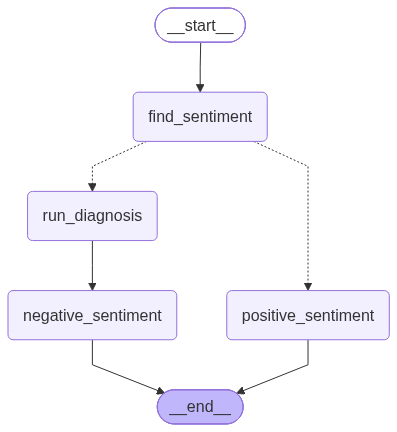

In [44]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [45]:
initial_state = {
    'review': "this product is worst to use but has some good points"
}
final_state = workflow.invoke(initial_state)
print(final_state)

{'sentiment': 'negative', 'review': 'this product is worst to use but has some good points', 'response': AIMessage(content='**Subject:** We’ve received your bug report – thank you for letting us know\n\nHi\u202f[Customer Name],\n\nThank you for taking the time to fill out our diagnosis form. I’m sorry to hear that you’re experiencing this issue and that it’s left you feeling disappointed. I understand how frustrating that can be, especially when you rely on our product to work smoothly.\n\n**What we’ve captured so far**\n\n| Detail | Information |\n|--------|--------------|\n| **Issue type** | Bug |\n| **Tone of your review** | Disappointed |\n| **Urgency level** | Moderate |\n| **Reference ID** | **#\u202f[XXXX‑XXXX]** |\n\n**Next steps**\n\n1. **Investigation:** Our engineering team has been alerted and will start reproducing the problem right away. Because the urgency is moderate, we’ve placed this bug in our current sprint and will aim to have a fix ready within the next\u202f5–7\u